In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import os

# Load data
file_names = ['Bangalore.csv', 'Chennai.csv', 'Hyderabad.csv']
dataframes = [pd.read_csv(file) for file in file_names]
df = pd.concat(dataframes, ignore_index=True)

In [36]:
#1. Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13739 entries, 0 to 13738
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Price                13739 non-null  int64 
 1   Area                 13739 non-null  int64 
 2   Location             13739 non-null  object
 3   No. of Bedrooms      13739 non-null  int64 
 4   Resale               13739 non-null  int64 
 5   MaintenanceStaff     13739 non-null  int64 
 6   Gymnasium            13739 non-null  int64 
 7   SwimmingPool         13739 non-null  int64 
 8   LandscapedGardens    13739 non-null  int64 
 9   JoggingTrack         13739 non-null  int64 
 10  RainWaterHarvesting  13739 non-null  int64 
 11  IndoorGames          13739 non-null  int64 
 12  ShoppingMall         13739 non-null  int64 
 13  Intercom             13739 non-null  int64 
 14  SportsFacility       13739 non-null  int64 
 15  ATM                  13739 non-null  int64 
 16  Club

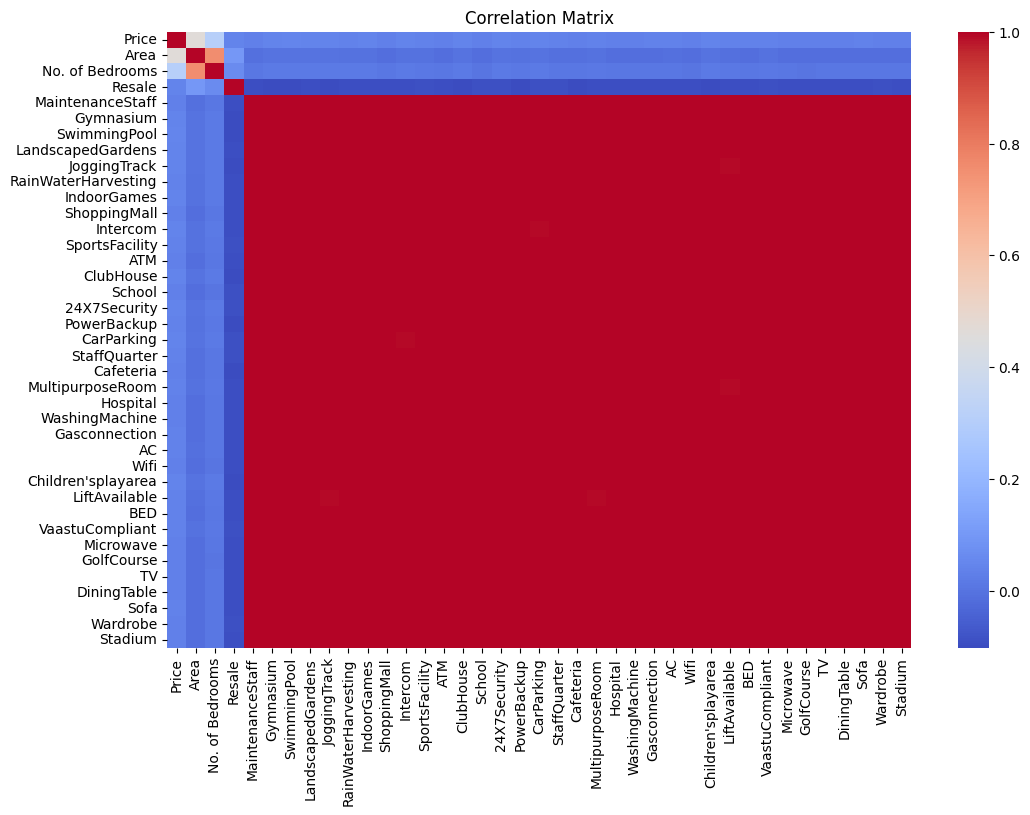

In [37]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(),  cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [67]:
df

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Stadium
0,30000000,3340,JP Nagar Phase 1,4,0,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
1,7888000,1045,Dasarahalli on Tumkur Road,2,0,0,1,1,1,1,...,1,0,1,0,0,0,0,0,0,0
2,4866000,1179,Kannur on Thanisandra Main Road,2,0,0,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
3,8358000,1675,Doddanekundi,3,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,6845000,1670,Kengeri,3,0,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13734,11000000,1460,Nacharam,2,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
13735,26000000,1314,Manikonda,2,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
13736,13300000,2625,Madhapur,3,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
13737,10800000,2050,Hitech City,3,0,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9


In [68]:
# Separate features and target
X = df.drop(['Price'], axis=1)
X = pd.get_dummies(X, dtype=int)
y = df['Price']

In [69]:
# Step 4: Train/Test Split
# ============
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ============
# Step 5: Modeling
# ============

def evaluate(model, name):
    print(f"R2: {r2_score(y_test, y_pred):.2f}, /nRMSE: {mean_squared_error(y_test, y_pred, squared=False):.2f}")
    joblib.dump(model, f"{name.replace(' ', '_').lower()}_model.pkl")

In [70]:
# Simple Linear Regression (just Area)
lr_simple = LinearRegression()
lr_simple.fit(X_train[['Area']], y_train)
y_pred = lr_simple.predict(X_test[['Area']])
print(f"R2:{r2_score(y_test, y_pred):.2f}",f"\nMSE: {mean_squared_error(y_test, y_pred):.2f}")


R2:0.19 
MSE: 158450587708911.66


In [72]:
# Multiple Linear Regression
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)
y_pred = lr_multi.predict(X_test)
print(f"R2:{r2_score(y_test, y_pred):.2f}",f"\nMSE: {mean_squared_error(y_test, y_pred):.2f}")

R2:0.24 
MSE: 148353250489709.75


In [76]:
# PCA + Linear Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, _, _ = train_test_split(X_pca, y, test_size=0.2, random_state=42)

lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
y_pred = lr_pca.predict(X_test_pca)
print(f"R2:{r2_score(y_test, y_pred):.2f}",f"\nMSE: {mean_squared_error(y_test, y_pred):.2f}")

R2:-1393291.22 
MSE: 273410030853964496896.00


In [77]:
# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)
print(f"R2:{r2_score(y_test, y_pred):.2f}",f"\nMSE: {mean_squared_error(y_test, y_pred):.2f}")

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print(f"R2:{r2_score(y_test, y_pred):.2f}",f"\nMSE: {mean_squared_error(y_test, y_pred):.2f}")

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.477e+17, tolerance: 1.436e+14
  model = cd_fast.enet_coordinate_descent(


R2:0.24 
MSE: 148508408459660.22
R2:0.25 
MSE: 147315719628892.47


In [79]:
# SVR
svr = SVR()
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)
print(f"R2:{r2_score(y_test, y_pred):.2f}",f"\nMSE: {mean_squared_error(y_test, y_pred):.2f}")

# Decision Tree
tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
print(f"R2:{r2_score(y_test, y_pred):.2f}",f"\nMSE: {mean_squared_error(y_test, y_pred):.2f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(f"R2:{r2_score(y_test, y_pred):.2f}",f"\nMSE: {mean_squared_error(y_test, y_pred):.2f}")

# GridSearchCV on Random Forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20]
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid_search.fit(X_train, y_train)

y_pred = grid_search.predict(X_test)
print(f"R2:{r2_score(y_test, y_pred):.2f}",f"\nMSE: {mean_squared_error(y_test, y_pred):.2f}")

print(" All models trained and saved.")

R2:-0.06 
MSE: 207450309322199.81
R2:0.25 
MSE: 146969583318233.50
R2:0.35 
MSE: 128143151153695.34
R2:0.37 
MSE: 123566549878448.30
 All models trained and saved.
